In [ ]:
import pandas as pd
df = pd.read_parquet("hf://datasets/gentaiscool/codemixqa/data/test-00000-of-00001.parquet")

In [ ]:
import os
import csv
import pandas as pd

def urls_to_idx(df, url_id_map):
    url_ids_column = []
    none_counter = 0
    for row in df.itertuples():
        list_of_urls = row.urls.split(",")
        list_of_url_ids = []
        for url in list_of_urls:
            url = url.strip()
            url_id = url_id_map.get(url, None)
            if url_id is not None:
                list_of_url_ids.append(url_id)
            else:
                none_counter += 1
        url_ids_column.append(list_of_url_ids)
    df["url_ids"] = url_ids_column
    return df, none_counter

def read_url_id_map(file_path):
    url_id_map = {}
    with open(file_path, mode='r') as infile:
        reader = csv.reader(infile)
        for rows in reader:
            url_id_map[rows[0]] = rows[1]
    return url_id_map

def load_scraped_data(lang, folder):
    folder_path = os.path.join(folder, lang)
    data = []
    for file in os.listdir(folder_path):
        if file.endswith(".txt"):
            path = os.path.join(folder_path, file)
            with open(path, "r", encoding="utf-8") as f:
                text = f.read()
                file_num = int(file.split(".")[0])
                data.append({"file_num": file_num, "text": text})
    return pd.DataFrame(data)

def get_passages(url_ids, file_text_map):
    passages = []
    none_counter = 0 
    for uid in url_ids:
        text = file_text_map.get(int(uid), None)
        if text is None:
            none_counter += 1
        else:
            passages.append(text)
    if len(passages) != len(url_ids) - none_counter:
        print("Mismatch:", len(url_ids), len(passages), none_counter)
    return passages, none_counter

df = pd.read_parquet("hf://datasets/gentaiscool/codemixqa/data/test-00000-of-00001.parquet")
url_id_map = read_url_id_map("url_id_map.csv")
# added the url ids to make it easier to fetch the corresponding passages later on
df, none_count = urls_to_idx(df, url_id_map)
print("Number of URLs with no ID:", none_count)
# english scraped data
df_scraped_en = load_scraped_data("en", "language_texts_translated")
file_text_map = dict(zip(df_scraped_en["file_num"], df_scraped_en["text"]))
df["passages"] = df["url_ids"].apply(lambda x: get_passages(x, file_text_map))

Number of URLs with no ID: 0


In [26]:
df

,id,original_index,problem,answer,topic,answer_type,multi_step,requires_reasoning,urls,method,language,url_ids,passages
0,2174-grammarforce_source-Bengali,2174,Which baseball field-এ Central Illinois Colleg...,Lloyd Hopkins Field,Sports,Place,False,False,https://www.altonbaseball.com/custom_pages/982...,grammarforce_source,Bengali,"[1981, 908]",[Lloyd Hopkins Field - Wikipedia Jump to conte...
1,2429-grammarforce_target-Urdu,2429,Tivoli Gardens میں Demon کے لیے جگہ بنانے کو ک...,The Snake,Other,Other,False,False,https://sophiessuitcase.com/a-guide-to-tivoli-...,grammarforce_target,Urdu,"[1768, 170, 1225]",[A Guide to Tivoli Gardens - Sophie's Suitcase...
2,3532-grammarforce_source-Hindi,3532,1898 में New York के state entomologist की 14t...,Byturus tomentosus,Science and technology,Other,True,False,https://nysl.ptfs.com/aw-server/rest/product/p...,grammarforce_source,Hindi,"[1608, 2339]",[14th Report of the State Entomologist on inju...
3,1452-selective-Italian,1452,After chi was Bullard Mountain named in the Bo...,Benjamin Bullard,Geography,Person,False,False,https://en.wikipedia.org/wiki/Bullard_Mountain...,selective,Italian,"[516, 334, 82]",[Bullard Mountain - Wikipedia Jump to content ...
4,4184-force-Japanese,4184,What four 健康組織 wrote to President ジョン・F・ケネディ c...,"American Cancer Society, the American Public H...",History,Other,False,False,https://www.ajmc.com/view/surgeon-generals-smo...,random,Japanese,"[1967, 232, 2565, 74]",[Surgeon General's 'Smoking and Health' Turns ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63995,4283-selective-Urdu transliterate,4283,kis month aur year mein Naughty Dog ke technol...,November 2023,Video games,Date,False,False,"https://en.wikipedia.org/wiki/Naughty_Dog,http...",selective,Urdu transliterate,"[1002, 60, 2930, 2296]",[Naughty Dog - Wikipedia Jump to content Main ...
63996,4287-selective-Urdu transliterate,4287,Which English singer aik film aur television c...,George Melly,Music,Person,False,False,https://tv.apple.com/us/person/george-melly/um...,selective,Urdu transliterate,"[1847, 689, 1569]",[âGeorge Melly Movies and Shows - Apple TV S...
63997,4291-selective-Urdu transliterate,4291,"MI5 ki pehli female DG kaun thi, aur pehla DG ...",Stella Rimington,Politics,Person,False,False,https://www.horus-security.co.uk/articles/nota...,selective,Urdu transliterate,"[2387, 1185, 1801]",[Notable Women in Security - Horus Security Co...
63998,4306-selective-Urdu transliterate,4306,William Holwell Carr ke walid kya karte the zi...,Apothecary,Art,Other,False,False,https://en.wikipedia.org/wiki/William_Holwell_...,selective,Urdu transliterate,"[1276, 2566]",[William Holwell Carr - Wikipedia Jump to cont...


In [ ]:
for row in df.itertuples():
    scraped_data_for_row = []
    for url_id in row.url_ids:
        scraped_data_for_row.append(df_scraped_en[df_scraped_en["file_num"] == int(url_id)]["text"].values)
    print(scraped_data_for_row)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [10]:
df["urls"][0].split(",")

['https://www.altonbaseball.com/custom_pages/98260/lloyd-hopkins-field',
 'https://en.wikipedia.org/wiki/Lloyd_Hopkins_Field']

In [35]:
import os
import pandas as pd

def load_scraped_data(lang, folder):
    folder_path = os.path.join(folder, lang)
    data = []
    for file in os.listdir(folder_path):
        if file.endswith(".txt"):
            path = os.path.join(folder_path, file)
            print(path)
            with open(path, "r", encoding="utf-8") as f:
                text = f.read()
                file_num = int(file.split(".")[0])
                data.append({"file_num": file_num, "text": text})
    return pd.DataFrame(data)

In [36]:
load_scraped_data("en", "language_texts_translated")

language_texts_translated/en/1053.txt
language_texts_translated/en/52.txt
language_texts_translated/en/1326.txt
language_texts_translated/en/1277.txt
language_texts_translated/en/1371.txt
language_texts_translated/en/2464.txt
language_texts_translated/en/1948.txt
language_texts_translated/en/1724.txt
language_texts_translated/en/840.txt
language_texts_translated/en/1364.txt
language_texts_translated/en/1687.txt
language_texts_translated/en/2544.txt
language_texts_translated/en/731.txt
language_texts_translated/en/2248.txt
language_texts_translated/en/1199.txt
language_texts_translated/en/363.txt
language_texts_translated/en/1002.txt
language_texts_translated/en/859.txt
language_texts_translated/en/2083.txt
language_texts_translated/en/730.txt
language_texts_translated/en/2421.txt
language_texts_translated/en/2275.txt
language_texts_translated/en/1753.txt
language_texts_translated/en/1143.txt
language_texts_translated/en/612.txt
language_texts_translated/en/1165.txt
language_texts_trans

,file_num,text
0,1053,Patty Berg - Wikipedia Jump to content Main me...
1,52,%PDF-1.5 %������������ 1820 0 obj < > endobj x...
2,1326,Kate Brown Just Became America's First-Ever Op...
3,1277,William II of Holland - Wikipedia Jump to cont...
4,1371,Glottolog 5.2 - Aralle-Tabulahan Glottolog Lan...
...,...,...
2414,1529,%PDF-1.3 %���� 4 0 obj << /Linearized 1 /O 6 /...
2415,2398,Activision Blizzard Announces New Esports Divi...
2416,517,Bure Nangal - Wikipedia Jump to content Main m...
2417,2479,Bust of Anima Dannata | LIECHTENSTEIN. The Pri...


## Dataset Overview & Basic Statistics

In [16]:
# Basic information
print(f"Dataset Shape: {df.shape}")
print(f"Total Samples: {len(df)}")
print(f"\nColumn Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nMemory Usage:")
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

Dataset Shape: (64000, 17)
Total Samples: 64000

Column Types:
id                    object
original_index         int64
problem               object
answer                object
topic                 object
answer_type           object
multi_step              bool
requires_reasoning      bool
urls                  object
method                object
language              object
question_length        int64
answer_length          int64
question_words         int64
answer_words           int64
has_url                 bool
num_urls               int64
dtype: object

Missing Values:
id                    0
original_index        0
problem               0
answer                0
topic                 0
answer_type           0
multi_step            0
requires_reasoning    0
urls                  0
method                0
language              0
question_length       0
answer_length         0
question_words        0
answer_words          0
has_url               0
num_urls              0
dtype

In [17]:
# Language distribution
print("Language Distribution:")
print(df['language'].value_counts())
print(f"\nUnique Languages: {df['language'].nunique()}")

Language Distribution:
language
Bengali                  4000
Urdu                     4000
Hindi                    4000
Italian                  4000
Japanese                 4000
Marathi                  4000
Spanish                  4000
Indonesian               4000
Korean                   4000
Simplified Chinese       4000
French                   4000
Toba Batak               4000
Bengali transliterate    4000
Hindi transliterate      4000
Marathi transliterate    4000
Urdu transliterate       4000
Name: count, dtype: int64

Unique Languages: 16


In [18]:
# Topic distribution
print("Topic Distribution:")
print(df['topic'].value_counts())
print(f"\nUnique Topics: {df['topic'].nunique()}")

Topic Distribution:
topic
Politics                  11264
Science and technology    10240
Art                        9280
Sports                     7488
Geography                  7104
Other                      6528
Music                      6528
History                    3328
TV shows                   1280
Video games                 960
Name: count, dtype: int64

Unique Topics: 10


In [19]:
# Answer type distribution
print("Answer Type Distribution:")
print(df['answer_type'].value_counts())

# Method distribution  
print("\n\nMethod Distribution:")
print(df['method'].value_counts())

Answer Type Distribution:
answer_type
Other     15936
Date      14208
Person    12672
Number    11840
Place      9344
Name: count, dtype: int64


Method Distribution:
method
grammarforce_source    16000
grammarforce_target    16000
selective              16000
random                 16000
Name: count, dtype: int64


In [7]:
# Complexity characteristics
print("Multi-step Questions:")
print(df['multi_step'].value_counts())

print("\n\nRequires Reasoning:")
print(df['requires_reasoning'].value_counts())

Multi-step Questions:
multi_step
False    59328
True      4672
Name: count, dtype: int64


Requires Reasoning:
requires_reasoning
False    61632
True      2368
Name: count, dtype: int64


## Text Length Analysis

In [20]:
# Question and answer length statistics
df['question_length'] = df['problem'].str.len()
df['answer_length'] = df['answer'].str.len()
df['question_words'] = df['problem'].str.split().str.len()
df['answer_words'] = df['answer'].str.split().str.len()

print("Question Length Statistics (characters):")
print(df['question_length'].describe())
print("\n\nAnswer Length Statistics (characters):")
print(df['answer_length'].describe())
print("\n\nQuestion Length Statistics (words):")
print(df['question_words'].describe())
print("\n\nAnswer Length Statistics (words):")
print(df['answer_words'].describe())

Question Length Statistics (characters):
count    64000.000000
mean        96.883062
std         44.194945
min          0.000000
25%         66.000000
50%         89.000000
75%        117.000000
max        423.000000
Name: question_length, dtype: float64


Answer Length Statistics (characters):
count    64000.000000
mean        18.349000
std         18.210722
min          1.000000
25%          7.000000
50%         13.000000
75%         21.000000
max        168.000000
Name: answer_length, dtype: float64


Question Length Statistics (words):
count    64000.000000
mean        15.796297
std          7.313618
min          0.000000
25%         11.000000
50%         15.000000
75%         19.000000
max         80.000000
Name: question_words, dtype: float64


Answer Length Statistics (words):
count    64000.000000
mean         2.923000
std          2.541097
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         22.000000
Name: answer_words, dtype: fl

## Sample Data Exploration

In [9]:
# Sample questions from different languages
import random

languages = df['language'].unique()[:5]
print("Sample Questions from Different Languages:\n")
for lang in languages:
    sample = df[df['language'] == lang].iloc[0]
    print(f"Language: {lang}")
    print(f"Question: {sample['problem']}")
    print(f"Answer: {sample['answer']}")
    print(f"Topic: {sample['topic']}")
    print(f"URL: {sample['urls'][:100]}...")
    print("-" * 100)
    print()

Sample Questions from Different Languages:

Language: Bengali
Question: Which baseball field-এ Central Illinois Collegiate League-এর Bluff City Bombers 1998 থেকে 2004 পর্যন্ত তাদের home games খেলত?
Answer: Lloyd Hopkins Field
Topic: Sports
URL: https://www.altonbaseball.com/custom_pages/98260/lloyd-hopkins-field,https://en.wikipedia.org/wiki/L...
----------------------------------------------------------------------------------------------------

Language: Urdu
Question: Tivoli Gardens میں Demon کے لیے جگہ بنانے کو کون سی attraction remove کی گئی تھی?
Answer: The Snake
Topic: Other
URL: https://sophiessuitcase.com/a-guide-to-tivoli-gardens/,https://berloga-workshop.com/blog/1046-tivoli...
----------------------------------------------------------------------------------------------------

Language: Hindi
Question: 1898 में New York के state entomologist की 14th report के अनुसार, Miss Ormerod ने अपनी 1893 की 15th report में England में raspberries को होने वाली गंभीर और व्यापक injuries क

## RAG Problem Assessment

In [10]:
# Analyze URL presence (key indicator for RAG)
df['has_url'] = df['urls'].notna() & (df['urls'] != '')
print("Questions with URLs (source documents):")
print(df['has_url'].value_counts())
print(f"\nPercentage with URLs: {(df['has_url'].sum() / len(df)) * 100:.2f}%")

# Multiple URLs per question
df['num_urls'] = df['urls'].str.split(',').str.len()
print("\n\nNumber of URLs per question:")
print(df['num_urls'].value_counts().sort_index())
print(f"\nAverage URLs per question: {df['num_urls'].mean():.2f}")

Questions with URLs (source documents):
has_url
True    64000
Name: count, dtype: int64

Percentage with URLs: 100.00%


Number of URLs per question:
num_urls
2    16640
3    34816
4    12032
5      448
6       64
Name: count, dtype: int64

Average URLs per question: 2.94


In [11]:
# RAG Suitability Analysis
print("=" * 100)
print("RAG PROBLEM SUITABILITY ASSESSMENT")
print("=" * 100)

print("\n✅ STRONG INDICATORS FOR RAG:")
print(f"1. URL-grounded answers: {(df['has_url'].sum() / len(df)) * 100:.1f}% of questions have source URLs")
print(f"2. Multiple sources: {(df['num_urls'] > 1).sum()} questions require multiple documents")
print(f"3. Factual answers: {(df['answer_type'].isin(['Person', 'Place', 'Date', 'Number'])).sum()} fact-based questions")
print(f"4. Diverse topics: {df['topic'].nunique()} different topics requiring diverse knowledge")

print("\n📊 COMPLEXITY FACTORS:")
print(f"1. Multi-step reasoning: {df['multi_step'].sum()} questions ({(df['multi_step'].sum()/len(df))*100:.1f}%)")
print(f"2. Requires reasoning: {df['requires_reasoning'].sum()} questions ({(df['requires_reasoning'].sum()/len(df))*100:.1f}%)")

print("\n🌍 CODE-MIXING CHALLENGE:")
print(f"1. Languages: {df['language'].nunique()} different languages/variants")
print(f"2. Mixed language questions require multilingual retrieval")

print("\n💡 RAG PIPELINE RECOMMENDATIONS:")
print("- Use multilingual embeddings (e.g., multilingual-e5, mE5-large)")
print("- Implement web scraping for URL-based document retrieval")
print("- Consider hybrid retrieval (dense + sparse) for code-mixed text")
print("- Use cross-lingual reranking for better relevance")
print("- Handle multi-hop reasoning for complex questions")

print("\n✨ CONCLUSION:")
print(f"This dataset is HIGHLY SUITABLE for RAG:")
print(f"  - {(df['has_url'].sum() / len(df)) * 100:.1f}% questions are grounded in external sources")
print(f"  - Questions require retrieving and reasoning over web documents")
print(f"  - Perfect testbed for multilingual RAG systems")

RAG PROBLEM SUITABILITY ASSESSMENT

✅ STRONG INDICATORS FOR RAG:
1. URL-grounded answers: 100.0% of questions have source URLs
2. Multiple sources: 64000 questions require multiple documents
3. Factual answers: 48064 fact-based questions
4. Diverse topics: 10 different topics requiring diverse knowledge

📊 COMPLEXITY FACTORS:
1. Multi-step reasoning: 4672 questions (7.3%)
2. Requires reasoning: 2368 questions (3.7%)

🌍 CODE-MIXING CHALLENGE:
1. Languages: 16 different languages/variants
2. Mixed language questions require multilingual retrieval

💡 RAG PIPELINE RECOMMENDATIONS:
- Use multilingual embeddings (e.g., multilingual-e5, mE5-large)
- Implement web scraping for URL-based document retrieval
- Consider hybrid retrieval (dense + sparse) for code-mixed text
- Use cross-lingual reranking for better relevance
- Handle multi-hop reasoning for complex questions

✨ CONCLUSION:
This dataset is HIGHLY SUITABLE for RAG:
  - 100.0% questions are grounded in external sources
  - Questions re

## Visualizations

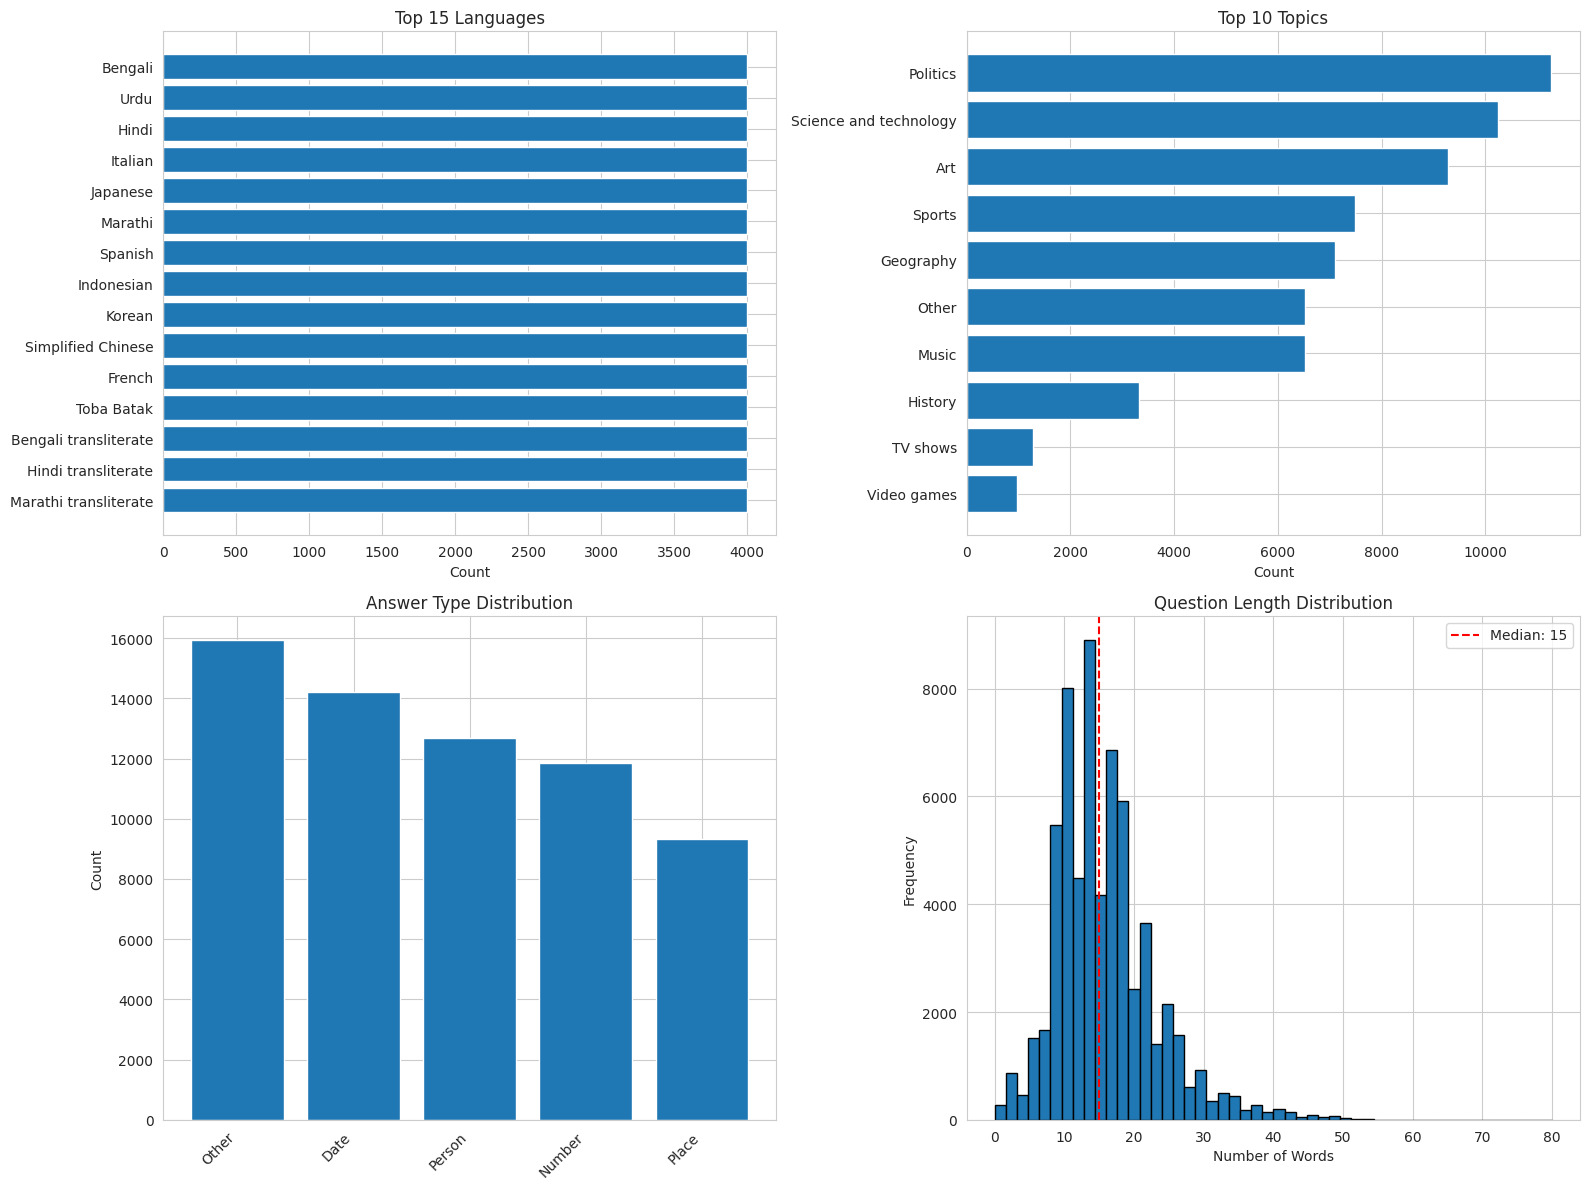

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Language distribution
top_langs = df['language'].value_counts().head(15)
axes[0, 0].barh(range(len(top_langs)), top_langs.values)
axes[0, 0].set_yticks(range(len(top_langs)))
axes[0, 0].set_yticklabels(top_langs.index)
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Top 15 Languages')
axes[0, 0].invert_yaxis()

# Topic distribution
top_topics = df['topic'].value_counts().head(10)
axes[0, 1].barh(range(len(top_topics)), top_topics.values)
axes[0, 1].set_yticks(range(len(top_topics)))
axes[0, 1].set_yticklabels(top_topics.index)
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_title('Top 10 Topics')
axes[0, 1].invert_yaxis()

# Answer type distribution
answer_types = df['answer_type'].value_counts()
axes[1, 0].bar(range(len(answer_types)), answer_types.values)
axes[1, 0].set_xticks(range(len(answer_types)))
axes[1, 0].set_xticklabels(answer_types.index, rotation=45, ha='right')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Answer Type Distribution')

# Question length distribution
axes[1, 1].hist(df['question_words'], bins=50, edgecolor='black')
axes[1, 1].set_xlabel('Number of Words')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Question Length Distribution')
axes[1, 1].axvline(df['question_words'].median(), color='red', linestyle='--', label=f'Median: {df["question_words"].median():.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## RAG Pipeline Prototype

In [13]:
# Proposed RAG Architecture for CodeMixQA

print("=" * 100)
print("PROPOSED RAG ARCHITECTURE FOR CODEMIXQA")
print("=" * 100)

print("\n📚 1. DOCUMENT CORPUS PREPARATION:")
print("   - Extract all unique URLs from the dataset")
print("   - Web scrape content from these URLs")
print("   - Clean and chunk documents (500-1000 tokens per chunk)")
print("   - Store metadata (topic, language, source URL)")

print("\n🔍 2. RETRIEVAL COMPONENT:")
print("   - Embeddings: multilingual-e5-large or mE5-base-v2")
print("   - Vector DB: FAISS, Qdrant, or Weaviate")
print("   - Hybrid retrieval: Dense (semantic) + BM25 (lexical)")
print("   - Cross-lingual capability for code-mixed queries")

print("\n🎯 3. RETRIEVAL STRATEGY:")
print("   - Top-k retrieval: k=5-10 documents")
print("   - Reranking: Use cross-encoder for better relevance")
print("   - Multi-hop: For multi_step questions, iterative retrieval")

print("\n🤖 4. GENERATION COMPONENT:")
print("   - LLM: GPT-4, Claude, or multilingual open models (Aya, BLOOM)")
print("   - Prompt template:")
print("      Context: {retrieved_documents}")
print("      Question: {code_mixed_question}")
print("      Answer in the same language style as the question.")

print("\n📊 5. EVALUATION METRICS:")
print("   - Retrieval: Recall@k, MRR, NDCG")
print("   - Generation: Exact Match, F1, ROUGE, BERTScore")
print("   - End-to-end: Answer accuracy on factual questions")

print("\n⚡ 6. OPTIMIZATION STRATEGIES:")
print("   - Cache frequently accessed documents")
print("   - Use smaller embedding models for faster retrieval")
print("   - Implement semantic caching for similar queries")
print("   - Quantize LLM for faster inference")

url_count = df['urls'].str.split(',').explode().nunique()
print(f"\n📈 DATASET STATS FOR RAG:")
print(f"   - Total unique URLs to scrape: ~{url_count:,}")
print(f"   - Questions requiring retrieval: {df['has_url'].sum():,} ({(df['has_url'].sum()/len(df))*100:.1f}%)")
print(f"   - Languages to support: {df['language'].nunique()}")
print(f"   - Topics to cover: {df['topic'].nunique()}")

PROPOSED RAG ARCHITECTURE FOR CODEMIXQA

📚 1. DOCUMENT CORPUS PREPARATION:
   - Extract all unique URLs from the dataset
   - Web scrape content from these URLs
   - Clean and chunk documents (500-1000 tokens per chunk)
   - Store metadata (topic, language, source URL)

🔍 2. RETRIEVAL COMPONENT:
   - Embeddings: multilingual-e5-large or mE5-base-v2
   - Vector DB: FAISS, Qdrant, or Weaviate
   - Hybrid retrieval: Dense (semantic) + BM25 (lexical)
   - Cross-lingual capability for code-mixed queries

🎯 3. RETRIEVAL STRATEGY:
   - Top-k retrieval: k=5-10 documents
   - Reranking: Use cross-encoder for better relevance
   - Multi-hop: For multi_step questions, iterative retrieval

🤖 4. GENERATION COMPONENT:
   - LLM: GPT-4, Claude, or multilingual open models (Aya, BLOOM)
   - Prompt template:
      Context: {retrieved_documents}
      Question: {code_mixed_question}
      Answer in the same language style as the question.

📊 5. EVALUATION METRICS:
   - Retrieval: Recall@k, MRR, NDCG
   -

In [14]:
# Extract unique URLs for document corpus
all_urls = df['urls'].str.split(',').explode().str.strip()
unique_urls = all_urls[all_urls.notna()].unique()

print(f"Total unique URLs in dataset: {len(unique_urls):,}")
print(f"\nSample URLs:")
for i, url in enumerate(unique_urls[:10], 1):
    print(f"{i}. {url}")

Total unique URLs in dataset: 2,939

Sample URLs:
1. https://www.altonbaseball.com/custom_pages/98260/lloyd-hopkins-field
2. https://en.wikipedia.org/wiki/Lloyd_Hopkins_Field
3. https://sophiessuitcase.com/a-guide-to-tivoli-gardens/
4. https://berloga-workshop.com/blog/1046-tivoli-gardens-copenhagen.html
5. https://en.wikipedia.org/wiki/Tivoli_Gardens
6. https://nysl.ptfs.com/aw-server/rest/product/purl/NYSL/i/7c2ef6f5-fc02-42c6-847e-de2ead5c0b60
7. https://www.google.com/books/edition/Report_of_the_State_Entomologist_on_Inju/IVThCDtf_8oC?hl=en&gbpv=1&dq=Miss+Ormerod
8. https://en.wikipedia.org/wiki/Bullard_Mountain
9. https://edits.nationalmap.gov/apps/gaz-domestic/public/search/names/1399563
10. https://alaska.guide/Mountain/Bullard-Mountain


## Challenge Analysis for RAG

In [15]:
# Analyze challenges by question complexity
print("=" * 100)
print("RAG CHALLENGES BY QUESTION TYPE")
print("=" * 100)

# Multi-step questions
print("\n🔗 MULTI-STEP QUESTIONS:")
multi_step_df = df[df['multi_step'] == True]
print(f"   Count: {len(multi_step_df):,} ({len(multi_step_df)/len(df)*100:.1f}%)")
print(f"   Challenge: Requires iterative retrieval (multi-hop RAG)")
print(f"   Languages: {multi_step_df['language'].nunique()}")
print("\n   Example:")
if len(multi_step_df) > 0:
    sample = multi_step_df.iloc[0]
    print(f"   Q: {sample['problem'][:150]}...")
    print(f"   A: {sample['answer']}")

# Reasoning-required questions
print("\n\n🧠 REASONING-REQUIRED QUESTIONS:")
reasoning_df = df[df['requires_reasoning'] == True]
print(f"   Count: {len(reasoning_df):,} ({len(reasoning_df)/len(df)*100:.1f}%)")
print(f"   Challenge: Need LLM to reason over retrieved context")
print("\n   Example:")
if len(reasoning_df) > 0:
    sample = reasoning_df.iloc[0]
    print(f"   Q: {sample['problem'][:150]}...")
    print(f"   A: {sample['answer']}")

# Code-mixing intensity analysis
print("\n\n🌐 CODE-MIXING CHALLENGE:")
print(f"   Languages/variants: {df['language'].nunique()}")
print(f"   Methods: {df['method'].value_counts().to_dict()}")
print(f"   Challenge: Embedding models must handle mixed-language text")
print(f"   Solution: Use multilingual embeddings trained on code-mixed data")

# Multiple source questions
multi_source = df[df['num_urls'] > 1]
print(f"\n\n📑 MULTI-SOURCE QUESTIONS:")
print(f"   Count: {len(multi_source):,} ({len(multi_source)/len(df)*100:.1f}%)")
print(f"   Max URLs per question: {df['num_urls'].max()}")
print(f"   Challenge: Information synthesis from multiple documents")
print(f"   Solution: Implement fusion-in-decoder or reranking across sources")

RAG CHALLENGES BY QUESTION TYPE

🔗 MULTI-STEP QUESTIONS:
   Count: 4,672 (7.3%)
   Challenge: Requires iterative retrieval (multi-hop RAG)
   Languages: 16

   Example:
   Q: 1898 में New York के state entomologist की 14th report के अनुसार, Miss Ormerod ने अपनी 1893 की 15th report में England में raspberries को होने वाली गं...
   A: Byturus tomentosus


🧠 REASONING-REQUIRED QUESTIONS:
   Count: 2,368 (3.7%)
   Challenge: Need LLM to reason over retrieved context

   Example:
   Q: Italian baritone Antonio Scotti (1866-1936) ke Metropolitan Opera House mein 1899 aur 1933 ke beech total kitni performances hui thi?...
   A: 1213 (acceptable range: anything between 1199 and 1226)


🌐 CODE-MIXING CHALLENGE:
   Languages/variants: 16
   Methods: {'grammarforce_source': 16000, 'grammarforce_target': 16000, 'selective': 16000, 'random': 16000}
   Challenge: Embedding models must handle mixed-language text
   Solution: Use multilingual embeddings trained on code-mixed data


📑 MULTI-SOURCE QUES

## Code-Mixing Analysis for Retrieval Experiments

In [21]:
# Detect code-mixing intensity using simple heuristics
import re

def detect_code_mixing(text):
    """
    Detect if text is code-mixed or monolingual English.
    Returns: 'pure_english', 'code_mixed', or 'non_english'
    """
    if not isinstance(text, str):
        return 'unknown'
    
    # Remove URLs and common English question words
    clean_text = re.sub(r'http\S+', '', text)
    
    # Count ASCII vs non-ASCII characters
    ascii_chars = sum(1 for c in clean_text if ord(c) < 128)
    non_ascii_chars = sum(1 for c in clean_text if ord(c) >= 128)
    
    total_alpha = ascii_chars + non_ascii_chars
    if total_alpha == 0:
        return 'unknown'
    
    non_ascii_ratio = non_ascii_chars / total_alpha
    
    # Check for common English patterns
    english_words = len(re.findall(r'\b[A-Za-z]+\b', clean_text))
    total_words = len(clean_text.split())
    
    if total_words == 0:
        return 'unknown'
    
    english_word_ratio = english_words / total_words
    
    # Classification logic
    if non_ascii_ratio < 0.05 and english_word_ratio > 0.85:
        return 'pure_english'
    elif non_ascii_ratio > 0.3:
        return 'non_english'  # Likely pure non-English with Latin script
    else:
        return 'code_mixed'

# Apply detection
df['mixing_type'] = df['problem'].apply(detect_code_mixing)

print("Code-Mixing Distribution:")
print(df['mixing_type'].value_counts())
print(f"\nPercentages:")
print(df['mixing_type'].value_counts(normalize=True) * 100)

Code-Mixing Distribution:
mixing_type
pure_english    33332
code_mixed      19798
non_english     10869
unknown             1
Name: count, dtype: int64

Percentages:
mixing_type
pure_english    52.081250
code_mixed      30.934375
non_english     16.982813
unknown          0.001563
Name: proportion, dtype: float64


In [22]:
# Detailed analysis by language and method
print("=" * 100)
print("CODE-MIXING PATTERNS BY LANGUAGE")
print("=" * 100)

for lang in df['language'].value_counts().head(10).index:
    lang_df = df[df['language'] == lang]
    mixing_dist = lang_df['mixing_type'].value_counts()
    print(f"\n{lang}:")
    print(f"  Total: {len(lang_df):,}")
    print(f"  Pure English: {mixing_dist.get('pure_english', 0):,} ({mixing_dist.get('pure_english', 0)/len(lang_df)*100:.1f}%)")
    print(f"  Code-Mixed: {mixing_dist.get('code_mixed', 0):,} ({mixing_dist.get('code_mixed', 0)/len(lang_df)*100:.1f}%)")
    print(f"  Non-English: {mixing_dist.get('non_english', 0):,} ({mixing_dist.get('non_english', 0)/len(lang_df)*100:.1f}%)")

CODE-MIXING PATTERNS BY LANGUAGE

Bengali:
  Total: 4,000
  Pure English: 50 (1.2%)
  Code-Mixed: 2,104 (52.6%)
  Non-English: 1,846 (46.2%)

Urdu:
  Total: 4,000
  Pure English: 198 (5.0%)
  Code-Mixed: 2,257 (56.4%)
  Non-English: 1,544 (38.6%)

Hindi:
  Total: 4,000
  Pure English: 1,557 (38.9%)
  Code-Mixed: 1,755 (43.9%)
  Non-English: 688 (17.2%)

Italian:
  Total: 4,000
  Pure English: 3,709 (92.7%)
  Code-Mixed: 291 (7.3%)
  Non-English: 0 (0.0%)

Japanese:
  Total: 4,000
  Pure English: 53 (1.3%)
  Code-Mixed: 2,088 (52.2%)
  Non-English: 1,859 (46.5%)

Marathi:
  Total: 4,000
  Pure English: 26 (0.7%)
  Code-Mixed: 1,591 (39.8%)
  Non-English: 2,383 (59.6%)

Spanish:
  Total: 4,000
  Pure English: 2,214 (55.4%)
  Code-Mixed: 1,786 (44.6%)
  Non-English: 0 (0.0%)

Indonesian:
  Total: 4,000
  Pure English: 3,850 (96.2%)
  Code-Mixed: 150 (3.8%)
  Non-English: 0 (0.0%)

Korean:
  Total: 4,000
  Pure English: 34 (0.9%)
  Code-Mixed: 2,411 (60.3%)
  Non-English: 1,555 (38.9%)

Si

In [23]:
# Examples of different mixing types
print("=" * 100)
print("EXAMPLES OF DIFFERENT CODE-MIXING PATTERNS")
print("=" * 100)

for mixing_type in ['pure_english', 'code_mixed', 'non_english']:
    samples = df[df['mixing_type'] == mixing_type].head(3)
    print(f"\n\n{mixing_type.upper().replace('_', ' ')} Examples:")
    print("-" * 100)
    for idx, row in samples.iterrows():
        print(f"\nLanguage: {row['language']}")
        print(f"Method: {row['method']}")
        print(f"Question: {row['problem'][:200]}")
        print(f"Answer: {row['answer']}")
        print()

EXAMPLES OF DIFFERENT CODE-MIXING PATTERNS


PURE ENGLISH Examples:
----------------------------------------------------------------------------------------------------

Language: Italian
Method: selective
Question: After chi was Bullard Mountain named in the Boundary Ranges in Alaska?
Answer: Benjamin Bullard


Language: Hindi
Method: selective
Question: Kaunsi former First Lady ne 1977 se 1978 tak Met Gala ki co-chair ke roop mein serve kiya?
Answer: Jackie Kennedy


Language: Urdu
Method: random
Question: Byturus tomentosus
Answer: Byturus tomentosus



CODE MIXED Examples:
----------------------------------------------------------------------------------------------------

Language: Bengali
Method: grammarforce_source
Question: Which baseball field-এ Central Illinois Collegiate League-এর Bluff City Bombers 1998 থেকে 2004 পর্যন্ত তাদের home games খেলত?
Answer: Lloyd Hopkins Field


Language: Hindi
Method: grammarforce_source
Question: 1898 में New York के state entomologist की 14th 

## Translation Strategy & Retrieval Experiment Design

In [24]:
# Experimental design to measure code-switching effect on retrieval
print("=" * 100)
print("EXPERIMENTAL DESIGN: CODE-SWITCHING EFFECT ON RETRIEVAL")
print("=" * 100)

print("\n📊 EXPERIMENT SETUP:")
print("\nDataset Splits by Mixing Type:")
for mixing_type in df['mixing_type'].unique():
    count = (df['mixing_type'] == mixing_type).sum()
    print(f"  {mixing_type}: {count:,} samples ({count/len(df)*100:.1f}%)")

print("\n\n🔬 PROPOSED EXPERIMENTS:")
print("\n1️⃣ BASELINE: Native Query Retrieval")
print("   - Use questions as-is (code-mixed)")
print("   - Embedding model: multilingual-e5-large")
print("   - Measure: Recall@k, MRR on document retrieval")

print("\n2️⃣ EXPERIMENT A: Full Translation to English")
print("   - Translate all questions to English")
print("   - Translate all documents to English")
print("   - Embedding model: English-only (e.g., bge-large-en)")
print("   - Hypothesis: May lose semantic nuances from code-mixing")

print("\n3️⃣ EXPERIMENT B: Query Translation Only")
print("   - Translate questions to English")
print("   - Keep documents in original language")
print("   - Embedding model: multilingual-e5-large")
print("   - Hypothesis: Cross-lingual retrieval performance")

print("\n4️⃣ EXPERIMENT C: Document Translation Only")
print("   - Keep questions code-mixed")
print("   - Translate documents to English")
print("   - Embedding model: multilingual-e5-large")
print("   - Hypothesis: May help with English-dominant models")

print("\n5️⃣ EXPERIMENT D: Hybrid Approach")
print("   - Create two indices: original + translated")
print("   - Retrieve from both, merge results")
print("   - Embedding model: multilingual-e5-large")
print("   - Hypothesis: Best of both worlds")

print("\n\n📈 EVALUATION METRICS:")
print("   - Recall@5, Recall@10: % of relevant docs retrieved")
print("   - MRR (Mean Reciprocal Rank): Position of first relevant doc")
print("   - NDCG@10: Ranking quality")
print("   - End-to-end QA accuracy: Final answer correctness")

print("\n\n🎯 KEY RESEARCH QUESTIONS:")
print("   1. Does code-mixing help or hurt retrieval?")
print("   2. Is translation necessary or does it lose information?")
print("   3. Which mixing pattern (pure_english, code_mixed, non_english) retrieves best?")
print("   4. Does multilingual embedding model handle code-mixing well?")

EXPERIMENTAL DESIGN: CODE-SWITCHING EFFECT ON RETRIEVAL

📊 EXPERIMENT SETUP:

Dataset Splits by Mixing Type:
  code_mixed: 19,798 samples (30.9%)
  non_english: 10,869 samples (17.0%)
  pure_english: 33,332 samples (52.1%)
  unknown: 1 samples (0.0%)


🔬 PROPOSED EXPERIMENTS:

1️⃣ BASELINE: Native Query Retrieval
   - Use questions as-is (code-mixed)
   - Embedding model: multilingual-e5-large
   - Measure: Recall@k, MRR on document retrieval

2️⃣ EXPERIMENT A: Full Translation to English
   - Translate all questions to English
   - Translate all documents to English
   - Embedding model: English-only (e.g., bge-large-en)
   - Hypothesis: May lose semantic nuances from code-mixing

3️⃣ EXPERIMENT B: Query Translation Only
   - Translate questions to English
   - Keep documents in original language
   - Embedding model: multilingual-e5-large
   - Hypothesis: Cross-lingual retrieval performance

4️⃣ EXPERIMENT C: Document Translation Only
   - Keep questions code-mixed
   - Translate doc

In [25]:
# Create stratified test sets for controlled experiments
from collections import defaultdict

# Group by mixing type
test_sets = {
    'pure_english': df[df['mixing_type'] == 'pure_english'],
    'code_mixed': df[df['mixing_type'] == 'code_mixed'],
    'non_english': df[df['mixing_type'] == 'non_english']
}

print("=" * 100)
print("TEST SET CREATION FOR CONTROLLED EXPERIMENTS")
print("=" * 100)

# Recommend sample sizes for experiments
sample_size = 500  # manageable for initial experiments

for mixing_type, subset in test_sets.items():
    print(f"\n{mixing_type.upper().replace('_', ' ')}:")
    print(f"  Total available: {len(subset):,}")
    print(f"  Recommended sample: {min(sample_size, len(subset))}")
    print(f"  Languages: {subset['language'].nunique()}")
    print(f"  Top languages: {', '.join(subset['language'].value_counts().head(3).index.tolist())}")

print("\n\n💡 RECOMMENDED APPROACH:")
print("   1. Sample 500 questions from each mixing type (balanced)")
print(f"   2. Total test set: {min(sample_size * 3, len(df))} questions")
print("   3. Retrieve documents from web using URLs")
print("   4. Run all 5 experiments on same test set")
print("   5. Compare retrieval performance across mixing types")

TEST SET CREATION FOR CONTROLLED EXPERIMENTS

PURE ENGLISH:
  Total available: 33,332
  Recommended sample: 500
  Languages: 16
  Top languages: Toba Batak, Urdu transliterate, Indonesian

CODE MIXED:
  Total available: 19,798
  Recommended sample: 500
  Languages: 16
  Top languages: Simplified Chinese, Korean, Urdu

NON ENGLISH:
  Total available: 10,869
  Recommended sample: 500
  Languages: 7
  Top languages: Marathi, Japanese, Bengali


💡 RECOMMENDED APPROACH:
   1. Sample 500 questions from each mixing type (balanced)
   2. Total test set: 1500 questions
   3. Retrieve documents from web using URLs
   4. Run all 5 experiments on same test set
   5. Compare retrieval performance across mixing types


## Translation Tools & Code-Mixing Preservation

In [26]:
# Translation strategy considerations
print("=" * 100)
print("TRANSLATION STRATEGIES FOR CODE-MIXED TEXT")
print("=" * 100)

print("\n🔧 TRANSLATION TOOLS:")
print("\n1. Google Translate API / Cloud Translation")
print("   ✅ Pros: High quality, supports many languages")
print("   ❌ Cons: Paid API, may not preserve code-mixing patterns")

print("\n2. NLLB (No Language Left Behind) - Meta")
print("   ✅ Pros: 200+ languages, open-source, code-mixing aware")
print("   ❌ Cons: Large model, slower inference")

print("\n3. Seamless M4T - Meta")
print("   ✅ Pros: Multilingual translation, recent model")
print("   ❌ Cons: Resource intensive")

print("\n4. mBART / mT5")
print("   ✅ Pros: Good multilingual coverage")
print("   ❌ Cons: May not handle code-mixing well")

print("\n5. IndicTrans2 (for Indian languages)")
print("   ✅ Pros: Specialized for Hindi, Bengali, Urdu, etc.")
print("   ❌ Cons: Limited to Indic languages")

print("\n\n⚠️  CODE-MIXING CHALLENGES:")
print("   1. Translating code-mixed text may lose semantic information")
print("   2. Named entities might get incorrectly translated")
print("   3. Cultural context may be lost")
print("   4. Grammar structures differ between languages")

print("\n\n✨ RECOMMENDED APPROACH:")
print("   1. Use NLLB-200 for translation (best code-mixing handling)")
print("   2. Preserve named entities (use NER before translation)")
print("   3. Create parallel corpus: original + translated")
print("   4. Use both for retrieval comparison")

print("\n\n📋 TRANSLATION WORKFLOW:")
print("   Step 1: Language detection for each question")
print("   Step 2: Named Entity Recognition (preserve entities)")
print("   Step 3: Translate non-entity text to English")
print("   Step 4: Re-insert entities in original form")
print("   Step 5: Post-process and validate translation quality")

TRANSLATION STRATEGIES FOR CODE-MIXED TEXT

🔧 TRANSLATION TOOLS:

1. Google Translate API / Cloud Translation
   ✅ Pros: High quality, supports many languages
   ❌ Cons: Paid API, may not preserve code-mixing patterns

2. NLLB (No Language Left Behind) - Meta
   ✅ Pros: 200+ languages, open-source, code-mixing aware
   ❌ Cons: Large model, slower inference

3. Seamless M4T - Meta
   ✅ Pros: Multilingual translation, recent model
   ❌ Cons: Resource intensive

4. mBART / mT5
   ✅ Pros: Good multilingual coverage
   ❌ Cons: May not handle code-mixing well

5. IndicTrans2 (for Indian languages)
   ✅ Pros: Specialized for Hindi, Bengali, Urdu, etc.
   ❌ Cons: Limited to Indic languages


⚠️  CODE-MIXING CHALLENGES:
   1. Translating code-mixed text may lose semantic information
   2. Named entities might get incorrectly translated
   3. Cultural context may be lost
   4. Grammar structures differ between languages


✨ RECOMMENDED APPROACH:
   1. Use NLLB-200 for translation (best code-mixi

In [27]:
# Sample translation demonstration (conceptual)
print("=" * 100)
print("SAMPLE TRANSLATION EXAMPLES")
print("=" * 100)

# Show what translation would look like for different mixing types
samples = {
    'code_mixed': df[df['mixing_type'] == 'code_mixed'].iloc[0] if len(df[df['mixing_type'] == 'code_mixed']) > 0 else None,
    'non_english': df[df['mixing_type'] == 'non_english'].iloc[0] if len(df[df['mixing_type'] == 'non_english']) > 0 else None,
}

for mixing_type, sample in samples.items():
    if sample is not None:
        print(f"\n{mixing_type.upper().replace('_', ' ')}:")
        print(f"Language: {sample['language']}")
        print(f"Original: {sample['problem']}")
        print(f"↓")
        print(f"Would translate to English for Experiment A")
        print(f"Answer: {sample['answer']}")
        print("-" * 100)

SAMPLE TRANSLATION EXAMPLES

CODE MIXED:
Language: Bengali
Original: Which baseball field-এ Central Illinois Collegiate League-এর Bluff City Bombers 1998 থেকে 2004 পর্যন্ত তাদের home games খেলত?
↓
Would translate to English for Experiment A
Answer: Lloyd Hopkins Field
----------------------------------------------------------------------------------------------------

NON ENGLISH:
Language: Urdu
Original: Tivoli Gardens میں Demon کے لیے جگہ بنانے کو کون سی attraction remove کی گئی تھی?
↓
Would translate to English for Experiment A
Answer: The Snake
----------------------------------------------------------------------------------------------------


## Expected Retrieval Performance by Mixing Type

In [28]:
# Hypothesis table for expected retrieval performance
import pandas as pd

# Create hypothesis table
hypotheses = {
    'Mixing Type': ['Pure English', 'Code-Mixed', 'Non-English'],
    'With Multilingual Embeddings': ['High (baseline)', 'Medium-High', 'Medium'],
    'After Translation to English': ['High (same)', 'Medium (loss of nuance)', 'High (if good translation)'],
    'With English-only Embeddings': ['Very High', 'Low', 'Very Low'],
    'Expected Challenge': [
        'None - standard retrieval',
        'Semantic drift in translation',
        'Complete language barrier without translation'
    ]
}

hypothesis_df = pd.DataFrame(hypotheses)
print("=" * 100)
print("HYPOTHESIZED RETRIEVAL PERFORMANCE")
print("=" * 100)
print("\n")
print(hypothesis_df.to_string(index=False))

print("\n\n📊 PREDICTED RETRIEVAL PERFORMANCE RANKING:")
print("\n1️⃣ PURE ENGLISH questions:")
print("   Best: English-only embeddings (e.g., bge-large-en)")
print("   Good: Multilingual embeddings")
print("   Impact of translation: Minimal (already English)")

print("\n2️⃣ CODE-MIXED questions:")
print("   Best: Multilingual embeddings WITHOUT translation")
print("   Good: Hybrid approach (original + translated)")
print("   Worse: Translation to English (loses code-mixing semantics)")
print("   Impact of translation: Potentially negative")

print("\n3️⃣ NON-ENGLISH questions:")
print("   Best: Translation to English + English embeddings")
print("   Good: Multilingual embeddings (if language supported)")
print("   Impact of translation: Highly positive")

print("\n\n🎯 KEY INSIGHT:")
print("   Code-mixing contains valuable semantic information!")
print("   Translation may help for pure non-English but hurt for code-mixed.")
print("   Recommendation: Use multilingual embeddings + keep code-mixing")

HYPOTHESIZED RETRIEVAL PERFORMANCE


 Mixing Type With Multilingual Embeddings After Translation to English With English-only Embeddings                            Expected Challenge
Pure English              High (baseline)                  High (same)                    Very High                     None - standard retrieval
  Code-Mixed                  Medium-High      Medium (loss of nuance)                          Low                 Semantic drift in translation
 Non-English                       Medium   High (if good translation)                     Very Low Complete language barrier without translation


📊 PREDICTED RETRIEVAL PERFORMANCE RANKING:

1️⃣ PURE ENGLISH questions:
   Best: English-only embeddings (e.g., bge-large-en)
   Good: Multilingual embeddings
   Impact of translation: Minimal (already English)

2️⃣ CODE-MIXED questions:
   Best: Multilingual embeddings WITHOUT translation
   Good: Hybrid approach (original + translated)
   Worse: Translation to English (los

## Implementation Roadmap

In [29]:
# Step-by-step implementation plan
print("=" * 100)
print("IMPLEMENTATION ROADMAP: CODE-SWITCHING EFFECT ON RETRIEVAL")
print("=" * 100)

print("\n📅 PHASE 1: Data Preparation (Week 1-2)")
print("   ✓ Analyze code-mixing patterns (DONE)")
print("   □ Sample 500 questions per mixing type")
print("   □ Scrape documents from URLs")
print("   □ Clean and chunk documents")
print("   □ Store in vector database (FAISS/Qdrant)")

print("\n📅 PHASE 2: Translation Pipeline (Week 2-3)")
print("   □ Set up NLLB-200 translation model")
print("   □ Translate questions to English")
print("   □ Translate documents to English")
print("   □ Quality check translations (sample)")
print("   □ Store parallel corpus")

print("\n📅 PHASE 3: Embedding & Indexing (Week 3-4)")
print("   □ Generate embeddings:")
print("      - multilingual-e5-large for all versions")
print("      - bge-large-en for English-only")
print("   □ Create indices:")
print("      - Original (code-mixed)")
print("      - Translated (English)")
print("      - Hybrid (both)")

print("\n📅 PHASE 4: Retrieval Experiments (Week 4-5)")
print("   □ Experiment 1: Baseline (code-mixed)")
print("   □ Experiment 2: Full translation")
print("   □ Experiment 3: Query translation only")
print("   □ Experiment 4: Document translation only")
print("   □ Experiment 5: Hybrid approach")
print("   □ Measure: Recall@5, Recall@10, MRR, NDCG")

print("\n📅 PHASE 5: Analysis & Reporting (Week 5-6)")
print("   □ Compare performance across mixing types")
print("   □ Statistical significance testing")
print("   □ Visualize results")
print("   □ Error analysis")
print("   □ Write report/paper")

print("\n\n💻 REQUIRED LIBRARIES:")
libs = [
    "transformers (HuggingFace)",
    "sentence-transformers",
    "faiss-cpu or faiss-gpu",
    "langdetect",
    "beautifulsoup4 (web scraping)",
    "datasets (HuggingFace)",
    "torch",
    "numpy, pandas",
    "scikit-learn",
    "matplotlib, seaborn"
]
for lib in libs:
    print(f"   - {lib}")

print("\n\n⚡ COMPUTATIONAL REQUIREMENTS:")
print("   - GPU: Recommended for embeddings (A100/V100)")
print("   - RAM: 32GB+ for large-scale indexing")
print("   - Storage: ~100GB for documents + embeddings")
print("   - Time: ~40 hours total for full pipeline")

IMPLEMENTATION ROADMAP: CODE-SWITCHING EFFECT ON RETRIEVAL

📅 PHASE 1: Data Preparation (Week 1-2)
   ✓ Analyze code-mixing patterns (DONE)
   □ Sample 500 questions per mixing type
   □ Scrape documents from URLs
   □ Clean and chunk documents
   □ Store in vector database (FAISS/Qdrant)

📅 PHASE 2: Translation Pipeline (Week 2-3)
   □ Set up NLLB-200 translation model
   □ Translate questions to English
   □ Translate documents to English
   □ Quality check translations (sample)
   □ Store parallel corpus

📅 PHASE 3: Embedding & Indexing (Week 3-4)
   □ Generate embeddings:
      - multilingual-e5-large for all versions
      - bge-large-en for English-only
   □ Create indices:
      - Original (code-mixed)
      - Translated (English)
      - Hybrid (both)

📅 PHASE 4: Retrieval Experiments (Week 4-5)
   □ Experiment 1: Baseline (code-mixed)
   □ Experiment 2: Full translation
   □ Experiment 3: Query translation only
   □ Experiment 4: Document translation only
   □ Experiment 5: Hy